# LightGBM v2 Colab Memmap + ETA Monitor

Notebook này dùng cho bảng:

`project-79499e5c-69d7-42b8-864.steam_gold.gold_lgbm_train_features_v2_colab_clean`

Mục tiêu:

1. Export bảng BigQuery sang GCS Parquet.
2. Đọc Parquet theo batch để tránh tràn RAM.
3. Ghi dữ liệu ra `numpy.memmap`.
4. Train LightGBM.
5. Theo dõi thời gian chi tiết: tạo dataset, mỗi vòng train, ETA còn lại.
6. Đánh giá AUC, Average Precision, Recall@K, NDCG@K.
7. Lưu model, metrics, feature importance lên Google Drive.

Điểm quan trọng: notebook **không dùng `pd.read_parquet()` full**.

In [1]:
# ============================================================
# 0. Cài thư viện
# ============================================================
!pip install -q google-cloud-bigquery google-cloud-bigquery-storage gcsfs pyarrow lightgbm scikit-learn pandas numpy matplotlib

In [2]:
# ============================================================
# 1. Auth Google Cloud + Mount Google Drive
# ============================================================
from google.colab import auth, drive

auth.authenticate_user()
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# 2. Config
# ============================================================
import os
import json
import gc
import time
from datetime import datetime, timedelta

import numpy as np
import pandas as pd

PROJECT_ID = "project-79499e5c-69d7-42b8-864"
DATASET_ID = "steam_gold"
TABLE_NAME = "gold_lgbm_train_features_v2_colab_clean"
SOURCE_TABLE = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}"

BUCKET = "truong_bigdata_24032026_init"

GCS_EXPORT_PREFIX = "steam/gold/lgbm_train_features_v2_colab_clean_export"
GCS_EXPORT_DIR = f"gs://{BUCKET}/{GCS_EXPORT_PREFIX}"
GCS_EXPORT_URI = f"{GCS_EXPORT_DIR}/*.parquet"

# Khuyên dùng local disk Colab để memmap nhanh hơn Drive.
# Train xong model/metrics sẽ được copy/lưu vào Drive.
WORK_DIR = "/content/steam_lgbm_v2_memmap_eta"
DRIVE_OUT_DIR = "/content/drive/MyDrive/steam_lgbm_v2_memmap_eta"

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

print("SOURCE_TABLE:", SOURCE_TABLE)
print("GCS_EXPORT_DIR:", GCS_EXPORT_DIR)
print("GCS_EXPORT_URI:", GCS_EXPORT_URI)
print("WORK_DIR:", WORK_DIR)
print("DRIVE_OUT_DIR:", DRIVE_OUT_DIR)

SOURCE_TABLE: project-79499e5c-69d7-42b8-864.steam_gold.gold_lgbm_train_features_v2_colab_clean
GCS_EXPORT_DIR: gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export
GCS_EXPORT_URI: gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/*.parquet
WORK_DIR: /content/steam_lgbm_v2_memmap_eta
DRIVE_OUT_DIR: /content/drive/MyDrive/steam_lgbm_v2_memmap_eta


In [4]:
# ============================================================
# 3. Hàm format thời gian và timer tổng
# ============================================================
def fmt_seconds(seconds):
    seconds = int(seconds)
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60

    if h > 0:
        return f"{h}h {m}m {s}s"
    if m > 0:
        return f"{m}m {s}s"
    return f"{s}s"

overall_start = time.time()
print("Notebook start:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Notebook start: 2026-05-28 08:32:22


## 4. Kiểm tra BigQuery table và export ra GCS

Nếu bạn đã export rồi, để:

```python
DO_EXPORT = False
DELETE_OLD_EXPORT = False
```

Nếu muốn export lại từ đầu, dùng:

```python
DELETE_OLD_EXPORT = True
DO_EXPORT = True
```

In [5]:
# ============================================================
# 4A. Kiểm tra bảng BigQuery
# ============================================================
from google.cloud import bigquery

bq_client = bigquery.Client(project=PROJECT_ID)

check_sql = f'''
SELECT
  COUNT(*) AS total_rows,
  SUM(label) AS positives,
  COUNT(*) - SUM(label) AS negatives,
  ROUND(SAFE_DIVIDE(SUM(label), COUNT(*)) * 100, 4) AS positive_rate_percent,
  COUNT(DISTINCT user_id) AS users,
  COUNT(DISTINCT app_id) AS apps
FROM `{SOURCE_TABLE}`;
'''

stats_df = bq_client.query(check_sql).to_dataframe()
display(stats_df)

,total_rows,positives,negatives,positive_rate_percent,users,apps
0,16846271,1425281,15420990,8.4605,3084198,1092


In [6]:
# ============================================================
# 4B. Xóa export cũ nếu cần
# ============================================================
DELETE_OLD_EXPORT = False  # đổi True nếu muốn xóa folder export cũ

if DELETE_OLD_EXPORT:
    !gsutil -m rm -r {GCS_EXPORT_DIR} || true
    print("Deleted old export:", GCS_EXPORT_DIR)
else:
    print("Skip deleting old export.")

Skip deleting old export.


In [7]:
# ============================================================
# 4C. Export BigQuery table sang GCS Parquet
# ============================================================
DO_EXPORT = False  # đổi True nếu chưa export hoặc muốn export lại

if DO_EXPORT:
    export_sql = f'''
    EXPORT DATA OPTIONS(
      uri = '{GCS_EXPORT_URI}',
      format = 'PARQUET',
      overwrite = true
    ) AS
    SELECT *
    FROM `{SOURCE_TABLE}`;
    '''

    print(export_sql)
    t0 = time.time()
    job = bq_client.query(export_sql)
    job.result()
    print("Export done in:", fmt_seconds(time.time() - t0))
    print("Export path:", GCS_EXPORT_URI)
else:
    print("Skip export. Using existing GCS Parquet files:", GCS_EXPORT_URI)

Skip export. Using existing GCS Parquet files: gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/*.parquet


In [8]:
# ============================================================
# 4D. SQL export để copy chạy trong BigQuery Console nếu cần
# ============================================================
export_sql_for_console = f'''
EXPORT DATA OPTIONS(
  uri = '{GCS_EXPORT_URI}',
  format = 'PARQUET',
  overwrite = true
) AS
SELECT *
FROM `{SOURCE_TABLE}`;
'''

print(export_sql_for_console)


EXPORT DATA OPTIONS(
  uri = 'gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/*.parquet',
  format = 'PARQUET',
  overwrite = true
) AS
SELECT *
FROM `project-79499e5c-69d7-42b8-864.steam_gold.gold_lgbm_train_features_v2_colab_clean`;



In [9]:
# ============================================================
# 4E. Kiểm tra file trên GCS
# ============================================================
!gsutil ls -lh {GCS_EXPORT_DIR}/ | head -50

 10.99 MiB  2026-05-28T05:07:15Z  gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000000.parquet
 10.97 MiB  2026-05-28T05:07:16Z  gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000001.parquet
 10.99 MiB  2026-05-28T05:07:15Z  gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000002.parquet
 10.93 MiB  2026-05-28T05:07:15Z  gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000003.parquet
 10.93 MiB  2026-05-28T05:07:15Z  gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000004.parquet
 11.07 MiB  2026-05-28T05:07:16Z  gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000005.parquet
 11.01 MiB  2026-05-28T05:07:15Z  gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000006.parquet
 10.99

## 5. Tạo PyArrow Dataset từ GCS

Dùng `gcsfs` để tránh lỗi wildcard `gs://.../*.parquet`.

In [10]:
# ============================================================
# 5. Tạo PyArrow dataset từ danh sách file Parquet trên GCS
# ============================================================
import gcsfs
import pyarrow as pa
import pyarrow.dataset as ds

fs = gcsfs.GCSFileSystem(project=PROJECT_ID)

gcs_glob_path = f"{BUCKET}/{GCS_EXPORT_PREFIX}/*.parquet"
parquet_files = fs.glob(gcs_glob_path)

if len(parquet_files) == 0:
    raise FileNotFoundError(
        f"Không tìm thấy file parquet tại gs://{gcs_glob_path}. "
        "Hãy export bảng BigQuery ra GCS trước."
    )

print("Num parquet files:", len(parquet_files))
print("First files:")
for p in parquet_files[:5]:
    print("gs://" + p)

dataset = ds.dataset(parquet_files, format="parquet", filesystem=fs)
print(dataset.schema)

Num parquet files: 167
First files:
gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000000.parquet
gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000001.parquet
gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000002.parquet
gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000003.parquet
gs://truong_bigdata_24032026_init/steam/gold/lgbm_train_features_v2_colab_clean_export/000000000004.parquet
user_id: int64
app_id: int64
label: int64
als_score: double
als_rank: int64
als_inverse_rank: double
als_rank_log: double
days_since_release: int64
game_win: int64
game_mac: int64
game_linux: int64
platform_count: int64
is_cross_platform: int64
platform_score: double
steam_deck: int64
steam_deck_score: double
positive_ratio: double
user_reviews: double
user_reviews_final: double
review_count_all_reviews: double
review_co

In [11]:
# ============================================================
# 6. Chọn feature columns từ schema
# ============================================================
all_cols = dataset.schema.names
print("Total columns:", len(all_cols))
print(all_cols)

ID_COLS = ["user_id", "app_id"]
LABEL_COL = "label"

# Các cột toàn 0 / vô nghĩa đã phát hiện
USELESS_COLS = [
    "avg_funny",
    "positive_review_share",
    "avg_recommendation_hours",
    "recommended_count",
    "positive_review_count",
    "game_rating",
    "negative_review_count",
    "avg_helpful",
]

DROP_COLS = set(ID_COLS + [LABEL_COL] + USELESS_COLS)

feature_cols = []
skipped_cols = []

for field in dataset.schema:
    name = field.name

    if name in DROP_COLS:
        skipped_cols.append((name, str(field.type), "drop/id/label/useless"))
        continue

    is_numeric = (
        pa.types.is_integer(field.type)
        or pa.types.is_floating(field.type)
        or pa.types.is_boolean(field.type)
        or pa.types.is_decimal(field.type)
    )

    if is_numeric:
        feature_cols.append(name)
    else:
        skipped_cols.append((name, str(field.type), "non_numeric"))

READ_COLS = ID_COLS + [LABEL_COL] + feature_cols

print("Num features:", len(feature_cols))
print("Feature cols:")
print(feature_cols)

print("\nSkipped cols:")
for item in skipped_cols:
    print(item)

feature_cols_path = os.path.join(WORK_DIR, "lightgbm_v2_feature_cols.json")
with open(feature_cols_path, "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

print("\nSaved feature cols:", feature_cols_path)

Total columns: 71
['user_id', 'app_id', 'label', 'als_score', 'als_rank', 'als_inverse_rank', 'als_rank_log', 'days_since_release', 'game_win', 'game_mac', 'game_linux', 'platform_count', 'is_cross_platform', 'platform_score', 'steam_deck', 'steam_deck_score', 'positive_ratio', 'user_reviews', 'user_reviews_final', 'review_count_all_reviews', 'review_count_final', 'recommendation_event_count', 'price_final_clean', 'price_original_clean', 'discount', 'is_free', 'quality_score', 'popularity_score', 'engagement_score', 'price_attractiveness_score', 'recency_score', 'game_profile_score', 'language_score', 'has_language_match', 'matched_language_count', 'matched_user_review_count', 'matched_game_review_count', 'max_single_language_match_score', 'als_x_language_score', 'v2_content_similarity_score', 'v2_content_distance', 'v2_content_similarity_centered', 'v2_content_similarity_percent_rank', 'v2_content_similarity_cume_dist', 'v2_content_similarity_rank', 'v2_has_content_similarity', 'v2_re

In [12]:
# ============================================================
# 7. Đếm số dòng và ước lượng dung lượng memmap
# ============================================================
t0 = time.time()
num_rows = dataset.count_rows()
count_time = time.time() - t0

num_features = len(feature_cols)
estimated_x_gb = num_rows * num_features * 4 / (1024**3)

print("Rows:", f"{num_rows:,}")
print("Features:", num_features)
print("Count rows time:", fmt_seconds(count_time))
print(f"Estimated X memmap float32 size: {estimated_x_gb:.2f} GB")

Rows: 16,846,271
Features: 68
Count rows time: 3m 6s
Estimated X memmap float32 size: 4.27 GB


## 6. Tạo memmap và ghi dữ liệu theo batch

Nếu bước ghi batch bị RAM, giảm:

```python
BATCH_SIZE = 50_000
```

Nếu muốn chạy lại từ đầu, để:

```python
RECREATE_MEMMAP = True
WRITE_MEMMAP = True
```

In [13]:
# ============================================================
# 8. Tạo memmap files
# ============================================================
X_path = os.path.join(WORK_DIR, "X_float32.dat")
y_path = os.path.join(WORK_DIR, "y_int8.dat")
user_path = os.path.join(WORK_DIR, "user_id_int64.dat")
app_path = os.path.join(WORK_DIR, "app_id_int64.dat")
meta_path = os.path.join(WORK_DIR, "memmap_meta.json")

RECREATE_MEMMAP = True

if RECREATE_MEMMAP:
    for p in [X_path, y_path, user_path, app_path]:
        if os.path.exists(p):
            os.remove(p)

    t0 = time.time()
    X_mm = np.memmap(X_path, dtype="float32", mode="w+", shape=(num_rows, num_features))
    y_mm = np.memmap(y_path, dtype="int8", mode="w+", shape=(num_rows,))
    user_mm = np.memmap(user_path, dtype="int64", mode="w+", shape=(num_rows,))
    app_mm = np.memmap(app_path, dtype="int64", mode="w+", shape=(num_rows,))

    meta = {
        "num_rows": int(num_rows),
        "num_features": int(num_features),
        "feature_cols": feature_cols,
        "X_path": X_path,
        "y_path": y_path,
        "user_path": user_path,
        "app_path": app_path,
        "source_table": SOURCE_TABLE,
        "gcs_export_dir": GCS_EXPORT_DIR,
        "gcs_export_uri": GCS_EXPORT_URI,
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print("Memmap created in:", fmt_seconds(time.time() - t0))
else:
    print("Skip creating memmap.")

Memmap created in: 0s


In [14]:
# ============================================================
# 9. Đọc Parquet theo batch → ghi memmap có ETA
# ============================================================
BATCH_SIZE = 100_000
WRITE_MEMMAP = True

if WRITE_MEMMAP:
    X_mm = np.memmap(X_path, dtype="float32", mode="r+", shape=(num_rows, num_features))
    y_mm = np.memmap(y_path, dtype="int8", mode="r+", shape=(num_rows,))
    user_mm = np.memmap(user_path, dtype="int64", mode="r+", shape=(num_rows,))
    app_mm = np.memmap(app_path, dtype="int64", mode="r+", shape=(num_rows,))

    scanner = dataset.scanner(
        columns=READ_COLS,
        batch_size=BATCH_SIZE
    )

    offset = 0
    t_start = time.time()

    for i, batch in enumerate(scanner.to_batches()):
        batch_t0 = time.time()

        pdf = batch.to_pandas(split_blocks=True, self_destruct=True)
        n = len(pdf)

        user_mm[offset:offset+n] = pd.to_numeric(pdf["user_id"], errors="coerce").fillna(0).astype("int64").to_numpy()
        app_mm[offset:offset+n] = pd.to_numeric(pdf["app_id"], errors="coerce").fillna(0).astype("int64").to_numpy()
        y_mm[offset:offset+n] = pd.to_numeric(pdf[LABEL_COL], errors="coerce").fillna(0).astype("int8").to_numpy()

        feat_pdf = pdf[feature_cols].copy()
        feat_pdf = feat_pdf.replace([np.inf, -np.inf], 0).fillna(0)
        X_batch = feat_pdf.astype("float32", copy=False).to_numpy(copy=False)

        X_mm[offset:offset+n, :] = X_batch

        offset += n

        elapsed = time.time() - t_start
        progress = offset / num_rows
        eta = elapsed / max(progress, 1e-9) - elapsed
        batch_time = time.time() - batch_t0

        if i % 5 == 0 or offset >= num_rows:
            print(
                f"Batch {i:>5} | rows {offset:,}/{num_rows:,} "
                f"({progress*100:.2f}%) | batch {fmt_seconds(batch_time)} "
                f"| elapsed {fmt_seconds(elapsed)} | ETA {fmt_seconds(eta)}"
            )

        del pdf, feat_pdf, X_batch, batch
        gc.collect()

    X_mm.flush()
    y_mm.flush()
    user_mm.flush()
    app_mm.flush()

    print("Done writing memmap.")
    print("Rows written:", f"{offset:,}")
else:
    print("Skip writing memmap.")

Batch     0 | rows 100,000/16,846,271 (0.59%) | batch 0s | elapsed 4s | ETA 11m 11s
Batch     5 | rows 301,967/16,846,271 (1.79%) | batch 0s | elapsed 5s | ETA 5m 0s
Batch    10 | rows 603,400/16,846,271 (3.58%) | batch 0s | elapsed 7s | ETA 3m 32s
Batch    15 | rows 806,278/16,846,271 (4.79%) | batch 0s | elapsed 9s | ETA 3m 12s
Batch    20 | rows 1,108,873/16,846,271 (6.58%) | batch 0s | elapsed 12s | ETA 2m 53s
Batch    25 | rows 1,310,859/16,846,271 (7.78%) | batch 0s | elapsed 13s | ETA 2m 45s
Batch    30 | rows 1,612,933/16,846,271 (9.57%) | batch 0s | elapsed 16s | ETA 2m 35s
Batch    35 | rows 1,816,049/16,846,271 (10.78%) | batch 0s | elapsed 18s | ETA 2m 31s
Batch    40 | rows 2,117,734/16,846,271 (12.57%) | batch 0s | elapsed 20s | ETA 2m 24s
Batch    45 | rows 2,319,273/16,846,271 (13.77%) | batch 0s | elapsed 22s | ETA 2m 21s
Batch    50 | rows 2,621,184/16,846,271 (15.56%) | batch 0s | elapsed 25s | ETA 2m 18s
Batch    55 | rows 2,823,086/16,846,271 (16.76%) | batch 0s | 

In [15]:
# ============================================================
# 10. Load lại memmap read-only
# ============================================================
with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

num_rows = int(meta["num_rows"])
num_features = int(meta["num_features"])
feature_cols = meta["feature_cols"]

X = np.memmap(X_path, dtype="float32", mode="r", shape=(num_rows, num_features))
y = np.memmap(y_path, dtype="int8", mode="r", shape=(num_rows,))
user_ids = np.memmap(user_path, dtype="int64", mode="r", shape=(num_rows,))
app_ids = np.memmap(app_path, dtype="int64", mode="r", shape=(num_rows,))

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)
print("positive:", int(y.sum()))
print("positive rate:", float(y.mean() * 100))
print("first row features:", X[0, :10])

X: (16846271, 68) float32
y: (16846271,) int8
positive: 1425281
positive rate: 8.460513308850368
first row features: [4.5963672e-01 4.0000000e+01 2.5000000e-02 3.7135720e+00 5.0510000e+03
 1.0000000e+00 0.0000000e+00 0.0000000e+00 1.0000000e+00 0.0000000e+00]


## 7. Split train/valid

Mặc định split random theo dòng để tiết kiệm RAM. Kết quả từ ảnh trước của bạn khoảng:

- Train: 13.47M
- Valid: 3.36M

In [16]:
# ============================================================
# 11. Split train/valid
# ============================================================
from sklearn.model_selection import train_test_split

VALID_RATIO = 0.2
SEED = 42

rng = np.random.default_rng(SEED)

t0 = time.time()
all_idx = np.arange(num_rows, dtype=np.int64)
rng.shuffle(all_idx)

valid_size = int(num_rows * VALID_RATIO)
valid_idx = all_idx[:valid_size]
train_idx = all_idx[valid_size:]

print("Split time:", fmt_seconds(time.time() - t0))
print("Train rows:", f"{len(train_idx):,}")
print("Valid rows:", f"{len(valid_idx):,}")
print("Train positive rate:", float(y[train_idx].mean() * 100))
print("Valid positive rate:", float(y[valid_idx].mean() * 100))

Split time: 1s
Train rows: 13,477,017
Valid rows: 3,369,254
Train positive rate: 8.467526604737532
Valid positive rate: 8.432460123220155


In [17]:
# ============================================================
# 12. Giới hạn dòng train/valid nếu RAM không đủ
# ============================================================
# Nếu muốn chạy nhanh hơn, đổi:
# MAX_TRAIN_ROWS = 8_000_000
# MAX_VALID_ROWS = 1_000_000

MAX_TRAIN_ROWS = None
MAX_VALID_ROWS = None

if MAX_TRAIN_ROWS is not None and len(train_idx) > MAX_TRAIN_ROWS:
    train_idx_used = rng.choice(train_idx, size=MAX_TRAIN_ROWS, replace=False)
else:
    train_idx_used = train_idx

if MAX_VALID_ROWS is not None and len(valid_idx) > MAX_VALID_ROWS:
    valid_idx_used = rng.choice(valid_idx, size=MAX_VALID_ROWS, replace=False)
else:
    valid_idx_used = valid_idx

print("Train used:", f"{len(train_idx_used):,}")
print("Valid used:", f"{len(valid_idx_used):,}")
print("Train positive rate used:", float(y[train_idx_used].mean() * 100))
print("Valid positive rate used:", float(y[valid_idx_used].mean() * 100))

Train used: 13,477,017
Valid used: 3,369,254
Train positive rate used: 8.467526604737532
Valid positive rate used: 8.432460123220155


## 8. Tạo LightGBM Dataset có đo thời gian

Nếu cell này lâu, nghĩa là LightGBM đang build binary dataset / histogram bins.

In [18]:
# ============================================================
# 13. Tạo LightGBM Dataset có đo thời gian
# ============================================================
import lightgbm as lgb

dataset_start = time.time()

num_pos = int(y[train_idx_used].sum())
num_neg = int(len(train_idx_used) - num_pos)
scale_pos_weight = num_neg / max(num_pos, 1)

print("num_pos:", f"{num_pos:,}")
print("num_neg:", f"{num_neg:,}")
print("scale_pos_weight:", scale_pos_weight)
print("Train rows:", f"{len(train_idx_used):,}")
print("Valid rows:", f"{len(valid_idx_used):,}")
print("Num features:", len(feature_cols))

print("\nCreating train_set object...")
t0 = time.time()
train_set = lgb.Dataset(
    X[train_idx_used],
    label=y[train_idx_used],
    feature_name=feature_cols,
    free_raw_data=False
)
print("train_set object created in:", fmt_seconds(time.time() - t0))

print("\nCreating valid_set object...")
t0 = time.time()
valid_set = lgb.Dataset(
    X[valid_idx_used],
    label=y[valid_idx_used],
    feature_name=feature_cols,
    reference=train_set,
    free_raw_data=False
)
print("valid_set object created in:", fmt_seconds(time.time() - t0))

print("\nConstructing LightGBM binary dataset...")
t0 = time.time()
train_set.construct()
valid_set.construct()
construct_time = time.time() - t0

print("LightGBM dataset constructed in:", fmt_seconds(construct_time))
print("Total dataset preparation time:", fmt_seconds(time.time() - dataset_start))

num_pos: 1,141,170
num_neg: 12,335,847
scale_pos_weight: 10.809824127868767
Train rows: 13,477,017
Valid rows: 3,369,254
Num features: 68

Creating train_set object...
train_set object created in: 15s

Creating valid_set object...
valid_set object created in: 1s

Constructing LightGBM binary dataset...
LightGBM dataset constructed in: 55s
Total dataset preparation time: 1m 13s


In [19]:
# ============================================================
# 14. Callback theo dõi thời gian train + ETA
# ============================================================
class TrainTimeEstimator:
    def __init__(self, total_rounds, log_period=50):
        self.total_rounds = total_rounds
        self.log_period = log_period
        self.start_time = None
        self.last_time = None
        self.last_iter = 0

    def __call__(self, env):
        current_iter = env.iteration + 1

        if self.start_time is None:
            self.start_time = time.time()
            self.last_time = self.start_time
            self.last_iter = current_iter
            print("\nTraining started at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

        should_log = (
            current_iter == 1
            or current_iter % self.log_period == 0
            or current_iter == self.total_rounds
        )

        if should_log:
            now = time.time()
            elapsed = now - self.start_time

            avg_per_iter = elapsed / max(current_iter, 1)
            remaining_iters = max(self.total_rounds - current_iter, 0)
            eta_seconds = remaining_iters * avg_per_iter

            recent_iters = max(current_iter - self.last_iter, 1)
            recent_time = now - self.last_time
            recent_per_iter = recent_time / recent_iters
            eta_recent = remaining_iters * recent_per_iter

            finish_time_avg = datetime.now() + timedelta(seconds=eta_seconds)
            finish_time_recent = datetime.now() + timedelta(seconds=eta_recent)

            metric_texts = []
            for item in env.evaluation_result_list:
                data_name, metric_name, value, _ = item
                metric_texts.append(f"{data_name}-{metric_name}: {value:.6f}")

            print("\n" + "=" * 90)
            print(f"Iteration: {current_iter}/{self.total_rounds}")
            print("Elapsed:", fmt_seconds(elapsed))
            print("Avg time/iter:", f"{avg_per_iter:.3f}s")
            print("Recent time/iter:", f"{recent_per_iter:.3f}s")
            print("ETA by avg speed:", fmt_seconds(eta_seconds), "| finish around:", finish_time_avg.strftime("%H:%M:%S"))
            print("ETA by recent speed:", fmt_seconds(eta_recent), "| finish around:", finish_time_recent.strftime("%H:%M:%S"))
            print("Metrics:", " | ".join(metric_texts))
            print("=" * 90)

            self.last_time = now
            self.last_iter = current_iter

## 9. Train LightGBM có ETA

Sau 50 vòng đầu, bạn sẽ thấy ETA tương đối rõ.  
Nếu muốn test nhanh, đổi:

```python
NUM_BOOST_ROUND = 100
EARLY_STOPPING_ROUNDS = 20
LOG_PERIOD = 10
```

In [20]:
# ============================================================
# 15. Train LightGBM có log thời gian chi tiết
# ============================================================
NUM_BOOST_ROUND = 1000
EARLY_STOPPING_ROUNDS = 50
LOG_PERIOD = 50

params = {
    "objective": "binary",
    "metric": ["auc", "average_precision"],
    "boosting_type": "gbdt",

    "learning_rate": 0.03,
    "num_leaves": 63,
    "max_depth": -1,
    "min_data_in_leaf": 200,

    "feature_fraction": 0.85,
    "bagging_fraction": 0.85,
    "bagging_freq": 1,

    "lambda_l1": 0.0,
    "lambda_l2": 1.0,

    "scale_pos_weight": scale_pos_weight,

    "verbosity": -1,
    "seed": SEED,
    "num_threads": -1,
}

print("Training params:")
for k, v in params.items():
    print(f"{k}: {v}")

train_start = time.time()

time_estimator = TrainTimeEstimator(
    total_rounds=NUM_BOOST_ROUND,
    log_period=LOG_PERIOD
)

model = lgb.train(
    params,
    train_set,
    valid_sets=[train_set, valid_set],
    valid_names=["train", "valid"],
    num_boost_round=NUM_BOOST_ROUND,
    callbacks=[
        time_estimator,
        lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS),
        lgb.log_evaluation(period=LOG_PERIOD)
    ]
)

train_time = time.time() - train_start

print("\n" + "#" * 90)
print("TRAINING FINISHED")
print("Best iteration:", model.best_iteration)
print("Best score:", model.best_score)
print("Training time:", fmt_seconds(train_time))
print("Finished at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("#" * 90)

Training params:
objective: binary
metric: ['auc', 'average_precision']
boosting_type: gbdt
learning_rate: 0.03
num_leaves: 63
max_depth: -1
min_data_in_leaf: 200
feature_fraction: 0.85
bagging_fraction: 0.85
bagging_freq: 1
lambda_l1: 0.0
lambda_l2: 1.0
scale_pos_weight: 10.809824127868767
verbosity: -1
seed: 42
num_threads: -1

Training started at: 2026-05-28 08:40:06

Iteration: 1/1000
Elapsed: 0s
Avg time/iter: 0.003s
Recent time/iter: 0.003s
ETA by avg speed: 3s | finish around: 08:40:10
ETA by recent speed: 3s | finish around: 08:40:10
Metrics: train-auc: 0.801455 | train-average_precision: 0.326944 | valid-auc: 0.801365 | valid-average_precision: 0.326164
Training until validation scores don't improve for 50 rounds

Iteration: 50/1000
Elapsed: 12m 18s
Avg time/iter: 14.780s
Recent time/iter: 15.081s
ETA by avg speed: 3h 54m 0s | finish around: 12:46:26
ETA by recent speed: 3h 58m 47s | finish around: 12:51:13
Metrics: train-auc: 0.818350 | train-average_precision: 0.388542 | val

## 10. Predict + đánh giá có ETA

In [21]:
# ============================================================
# 16. Predict valid theo batch + AUC/AP có ETA
# ============================================================
from sklearn.metrics import roc_auc_score, average_precision_score

def predict_in_batches_with_eta(model, X_data, indices, batch_size=500_000):
    preds = np.empty(len(indices), dtype=np.float32)

    start_time = time.time()
    total = len(indices)

    for start in range(0, total, batch_size):
        end = min(start + batch_size, total)
        idx = indices[start:end]

        batch_t0 = time.time()

        preds[start:end] = model.predict(
            X_data[idx],
            num_iteration=model.best_iteration
        ).astype("float32")

        batch_time = time.time() - batch_t0
        elapsed = time.time() - start_time

        done = end
        progress = done / total
        eta = elapsed / max(progress, 1e-9) - elapsed

        print(
            f"Predicted {done:,}/{total:,} "
            f"({progress*100:.2f}%) | "
            f"batch time: {fmt_seconds(batch_time)} | "
            f"elapsed: {fmt_seconds(elapsed)} | "
            f"ETA: {fmt_seconds(eta)}"
        )

    return preds

pred_start = time.time()

valid_pred = predict_in_batches_with_eta(
    model,
    X,
    valid_idx_used,
    batch_size=500_000
)

valid_y = np.asarray(y[valid_idx_used], dtype=np.int8)

auc = roc_auc_score(valid_y, valid_pred)
ap = average_precision_score(valid_y, valid_pred)

pred_time = time.time() - pred_start

print("\nPrediction + evaluation done.")
print("Time:", fmt_seconds(pred_time))
print("Valid AUC:", auc)
print("Valid Average Precision:", ap)

Predicted 500,000/3,369,254 (14.84%) | batch time: 8m 30s | elapsed: 8m 30s | ETA: 48m 49s
Predicted 1,000,000/3,369,254 (29.68%) | batch time: 8m 39s | elapsed: 17m 10s | ETA: 40m 40s
Predicted 1,500,000/3,369,254 (44.52%) | batch time: 8m 32s | elapsed: 25m 42s | ETA: 32m 2s
Predicted 2,000,000/3,369,254 (59.36%) | batch time: 8m 45s | elapsed: 34m 28s | ETA: 23m 36s
Predicted 2,500,000/3,369,254 (74.20%) | batch time: 8m 32s | elapsed: 43m 1s | ETA: 14m 57s
Predicted 3,000,000/3,369,254 (89.04%) | batch time: 8m 41s | elapsed: 51m 43s | ETA: 6m 21s
Predicted 3,369,254/3,369,254 (100.00%) | batch time: 6m 25s | elapsed: 58m 8s | ETA: 0s

Prediction + evaluation done.
Time: 58m 11s
Valid AUC: 0.8382671738301537
Valid Average Precision: 0.44060044388156644


In [22]:
# ============================================================
# 17. Ranking metrics: Recall@K, NDCG@K
# ============================================================
def ranking_metrics_at_k(user_arr, label_arr, score_arr, ks=(5, 10, 20, 50), max_users=200_000):
    df_eval = pd.DataFrame({
        "user_id": user_arr,
        "label": label_arr,
        "score": score_arr
    })

    if max_users is not None:
        users = df_eval["user_id"].drop_duplicates()
        if len(users) > max_users:
            sampled_users = users.sample(max_users, random_state=42)
            df_eval = df_eval[df_eval["user_id"].isin(sampled_users)]

    df_eval = df_eval.sort_values(["user_id", "score"], ascending=[True, False])

    results = []
    grouped = df_eval.groupby("user_id", sort=False)

    for k in ks:
        recalls = []
        ndcgs = []

        for _, g in grouped:
            labels = g["label"].to_numpy()
            total_pos = labels.sum()

            if total_pos <= 0:
                continue

            top_labels = labels[:k]
            hits = top_labels.sum()

            recalls.append(hits / total_pos)

            discounts = 1.0 / np.log2(np.arange(2, len(top_labels) + 2))
            dcg = np.sum(top_labels * discounts)

            ideal_len = int(min(total_pos, k))
            ideal_discounts = 1.0 / np.log2(np.arange(2, ideal_len + 2))
            idcg = np.sum(ideal_discounts)

            ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

        results.append({
            "k": k,
            "recall": float(np.mean(recalls)) if recalls else 0.0,
            "ndcg": float(np.mean(ndcgs)) if ndcgs else 0.0,
            "users_evaluated": len(recalls)
        })

    return pd.DataFrame(results)

rank_start = time.time()

valid_users_used = np.asarray(user_ids[valid_idx_used], dtype=np.int64)

metrics_df = ranking_metrics_at_k(
    user_arr=valid_users_used,
    label_arr=valid_y,
    score_arr=valid_pred,
    ks=(5, 10, 20, 50),
    max_users=200_000
)

rank_time = time.time() - rank_start

print("Ranking metrics time:", fmt_seconds(rank_time))
display(metrics_df)

Ranking metrics time: 48s


,k,recall,ndcg,users_evaluated
0,5,0.99992,0.926509,24925
1,10,1.00000,0.926549,24925
2,20,1.00000,0.926549,24925
3,50,1.00000,0.926549,24925


## 11. Feature importance + lưu model lên Drive

In [23]:
# ============================================================
# 18. Feature importance + lưu model/metrics
# ============================================================
import pickle
import shutil

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_gain": model.feature_importance(importance_type="gain"),
    "importance_split": model.feature_importance(importance_type="split"),
}).sort_values("importance_gain", ascending=False)

display(importance_df.head(50))

model_txt_path = os.path.join(DRIVE_OUT_DIR, "lightgbm_v2_colab_memmap_eta_model.txt")
model_pkl_path = os.path.join(DRIVE_OUT_DIR, "lightgbm_v2_colab_memmap_eta_model.pkl")
feature_cols_drive_path = os.path.join(DRIVE_OUT_DIR, "lightgbm_v2_feature_cols.json")
importance_path = os.path.join(DRIVE_OUT_DIR, "lightgbm_v2_feature_importance.csv")
metrics_path = os.path.join(DRIVE_OUT_DIR, "lightgbm_v2_ranking_metrics.csv")
summary_path = os.path.join(DRIVE_OUT_DIR, "lightgbm_v2_training_summary.json")

model.save_model(model_txt_path)

with open(model_pkl_path, "wb") as f:
    pickle.dump(model, f)

with open(feature_cols_drive_path, "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

importance_df.to_csv(importance_path, index=False)
metrics_df.to_csv(metrics_path, index=False)

overall_time = time.time() - overall_start

summary = {
    "source_table": SOURCE_TABLE,
    "gcs_export_uri": GCS_EXPORT_URI,
    "num_rows_memmap": int(num_rows),
    "num_features": int(num_features),
    "train_rows": int(len(train_idx_used)),
    "valid_rows": int(len(valid_idx_used)),
    "train_positive_rate": float(y[train_idx_used].mean()),
    "valid_positive_rate": float(y[valid_idx_used].mean()),
    "scale_pos_weight": float(scale_pos_weight),
    "best_iteration": int(model.best_iteration),
    "valid_auc": float(auc),
    "valid_average_precision": float(ap),
    "dataset_construct_time_seconds": float(construct_time) if "construct_time" in globals() else None,
    "train_time_seconds": float(train_time) if "train_time" in globals() else None,
    "prediction_eval_time_seconds": float(pred_time) if "pred_time" in globals() else None,
    "ranking_metrics_time_seconds": float(rank_time) if "rank_time" in globals() else None,
    "overall_time_seconds": float(overall_time),
    "params": params,
    "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
}

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved files:")
print(model_txt_path)
print(model_pkl_path)
print(feature_cols_drive_path)
print(importance_path)
print(metrics_path)
print(summary_path)

print("\nOverall elapsed time:", fmt_seconds(overall_time))

,feature,importance_gain,importance_split
67,v2_taxonomy_x_semantic_similarity,2.589479e+07,1923
0,als_score,2.522759e+07,3036
50,v2_taxonomy_overlap_score,1.382391e+07,1875
14,user_reviews,9.720039e+06,5456
32,matched_user_review_count,9.029625e+06,3229
49,v2_matched_taxonomy_weight,8.564774e+06,3046
1,als_rank,2.652539e+06,1522
38,v2_content_similarity_centered,2.425358e+06,1353
36,v2_content_similarity_score,2.252920e+06,628
62,v2_als_x_taxonomy_overlap,2.221555e+06,1573


Saved files:
/content/drive/MyDrive/steam_lgbm_v2_memmap_eta/lightgbm_v2_colab_memmap_eta_model.txt
/content/drive/MyDrive/steam_lgbm_v2_memmap_eta/lightgbm_v2_colab_memmap_eta_model.pkl
/content/drive/MyDrive/steam_lgbm_v2_memmap_eta/lightgbm_v2_feature_cols.json
/content/drive/MyDrive/steam_lgbm_v2_memmap_eta/lightgbm_v2_feature_importance.csv
/content/drive/MyDrive/steam_lgbm_v2_memmap_eta/lightgbm_v2_ranking_metrics.csv
/content/drive/MyDrive/steam_lgbm_v2_memmap_eta/lightgbm_v2_training_summary.json

Overall elapsed time: 5h 12m 43s


In [24]:
# ============================================================
# 19. Tạo file top-K demo từ valid set cho Streamlit
# ============================================================
TOP_K_DEMO = 20
MAX_DEMO_USERS = 5000

demo_df = pd.DataFrame({
    "user_id": np.asarray(user_ids[valid_idx_used], dtype=np.int64),
    "app_id": np.asarray(app_ids[valid_idx_used], dtype=np.int64),
    "label": valid_y,
    "lgbm_score": valid_pred,
})

demo_users = demo_df["user_id"].drop_duplicates()
if len(demo_users) > MAX_DEMO_USERS:
    demo_users = demo_users.sample(MAX_DEMO_USERS, random_state=42)

demo_df = demo_df[demo_df["user_id"].isin(demo_users)].copy()

demo_df["rank"] = (
    demo_df.groupby("user_id")["lgbm_score"]
    .rank(method="first", ascending=False)
    .astype("int32")
)

demo_top = (
    demo_df[demo_df["rank"] <= TOP_K_DEMO]
    .sort_values(["user_id", "rank"])
    .reset_index(drop=True)
)

demo_path = os.path.join(DRIVE_OUT_DIR, "lightgbm_v2_valid_top20_demo.csv")
demo_top.to_csv(demo_path, index=False)

print("Demo file:", demo_path)
print(demo_top.shape)
display(demo_top.head(20))

Demo file: /content/drive/MyDrive/steam_lgbm_v2_memmap_eta/lightgbm_v2_valid_top20_demo.csv
(7806, 5)


,user_id,app_id,label,lgbm_score,rank
0,76561197960323012,638970,0,0.528068,1
1,76561197960348999,1030840,0,0.203582,1
2,76561197960387299,504370,0,0.273569,1
3,76561197960437227,2050650,0,0.171052,1
4,76561197960437227,1092790,0,0.006709,2
5,76561197960442661,674940,0,0.491665,1
6,76561197960451537,692850,0,0.285303,1
7,76561197960466087,1172470,0,0.391926,1
8,76561197960466087,1238840,0,0.106993,2
9,76561197960711299,271590,0,0.587546,1


,metric,value
0,Valid AUC,0.838267
1,Valid Average Precision,0.440600
2,Positive Rate,0.084325


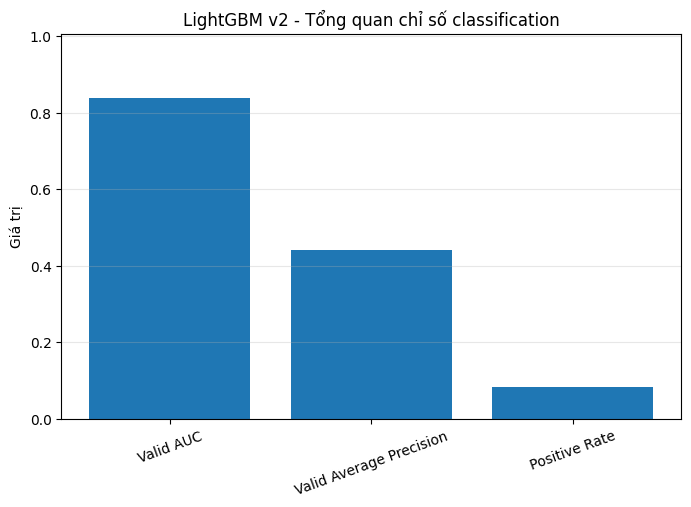

Nhận xét:
- Valid AUC = 0.8383: mô hình phân biệt positive/negative khá tốt.
- Valid AP = 0.4406: quan trọng với dữ liệu lệch nhãn.
- Positive rate gốc = 0.084325, AP cao hơn positive rate nhiều lần là dấu hiệu tốt.


In [26]:
# ============================================================
# 20.1. Tổng quan kết quả mô hình sau huấn luyện
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

valid_auc = roc_auc_score(valid_y, valid_pred)
valid_ap = average_precision_score(valid_y, valid_pred)
positive_rate = float(np.mean(valid_y))

summary_eval_df = pd.DataFrame({
    "metric": [
        "Valid AUC",
        "Valid Average Precision",
        "Positive Rate"
    ],
    "value": [
        valid_auc,
        valid_ap,
        positive_rate
    ]
})

display(summary_eval_df)

plt.figure(figsize=(8, 5))
plt.bar(summary_eval_df["metric"], summary_eval_df["value"])
plt.title("LightGBM v2 - Tổng quan chỉ số classification")
plt.ylabel("Giá trị")
plt.xticks(rotation=20)
plt.ylim(0, max(summary_eval_df["value"]) * 1.2)
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Nhận xét:")
print(f"- Valid AUC = {valid_auc:.4f}: mô hình phân biệt positive/negative khá tốt.")
print(f"- Valid AP = {valid_ap:.4f}: quan trọng với dữ liệu lệch nhãn.")
print(f"- Positive rate gốc = {positive_rate:.6f}, AP cao hơn positive rate nhiều lần là dấu hiệu tốt.")

,k,recall,ndcg,users_evaluated
0,5,0.99992,0.926509,24925
1,10,1.00000,0.926549,24925
2,20,1.00000,0.926549,24925
3,50,1.00000,0.926549,24925


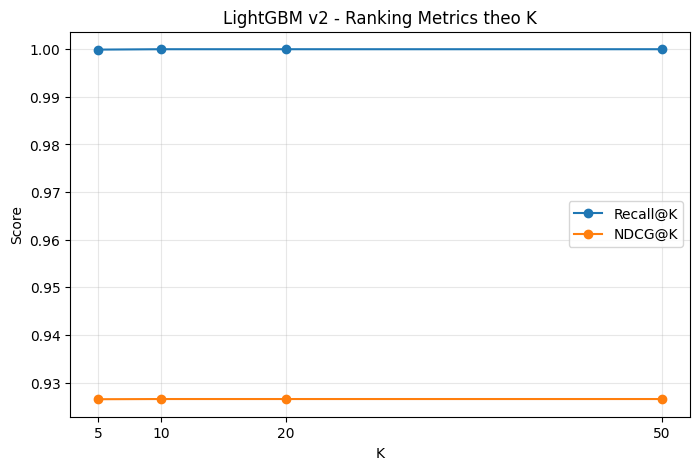

Nhận xét:
- Recall@K cho biết trong top-K recommendation, mô hình tìm lại được bao nhiêu item positive của user.
- NDCG@K có xét thứ hạng, positive nằm càng gần rank 1 thì NDCG càng cao.
- Nếu Recall/NDCG tăng khi K tăng là bình thường vì top-K rộng hơn sẽ có nhiều cơ hội chứa item đúng.


In [27]:
# ============================================================
# 20.2. Biểu đồ Recall@K và NDCG@K
# ============================================================

display(metrics_df)

plt.figure(figsize=(8, 5))
plt.plot(metrics_df["k"], metrics_df["recall"], marker="o", label="Recall@K")
plt.plot(metrics_df["k"], metrics_df["ndcg"], marker="o", label="NDCG@K")
plt.title("LightGBM v2 - Ranking Metrics theo K")
plt.xlabel("K")
plt.ylabel("Score")
plt.xticks(metrics_df["k"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Nhận xét:")
print("- Recall@K cho biết trong top-K recommendation, mô hình tìm lại được bao nhiêu item positive của user.")
print("- NDCG@K có xét thứ hạng, positive nằm càng gần rank 1 thì NDCG càng cao.")
print("- Nếu Recall/NDCG tăng khi K tăng là bình thường vì top-K rộng hơn sẽ có nhiều cơ hội chứa item đúng.")

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,3085143.0,0.331133,0.227734,0.00026,0.168715,0.300373,0.478991,0.997148
1,284111.0,0.667646,0.236669,0.00367,0.483442,0.706170,0.876228,0.999705


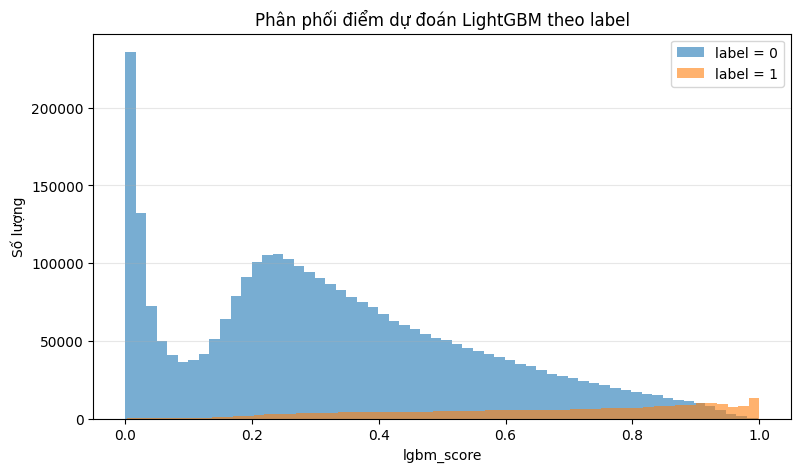

Nhận xét:
- Nếu phân phối label=1 lệch sang phải so với label=0, mô hình đang xếp item positive điểm cao hơn.
- Vì dữ liệu rất lệch nhãn, label=0 thường nhiều hơn rất nhiều nên biểu đồ label=0 sẽ áp đảo về số lượng.


In [28]:
# ============================================================
# 20.3. Phân phối lgbm_score theo label
# ============================================================

score_df = pd.DataFrame({
    "label": valid_y.astype(int),
    "lgbm_score": valid_pred.astype(float)
})

display(score_df.groupby("label")["lgbm_score"].describe())

plt.figure(figsize=(9, 5))
plt.hist(score_df.loc[score_df["label"] == 0, "lgbm_score"], bins=60, alpha=0.6, label="label = 0")
plt.hist(score_df.loc[score_df["label"] == 1, "lgbm_score"], bins=60, alpha=0.6, label="label = 1")
plt.title("Phân phối điểm dự đoán LightGBM theo label")
plt.xlabel("lgbm_score")
plt.ylabel("Số lượng")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Nhận xét:")
print("- Nếu phân phối label=1 lệch sang phải so với label=0, mô hình đang xếp item positive điểm cao hơn.")
print("- Vì dữ liệu rất lệch nhãn, label=0 thường nhiều hơn rất nhiều nên biểu đồ label=0 sẽ áp đảo về số lượng.")

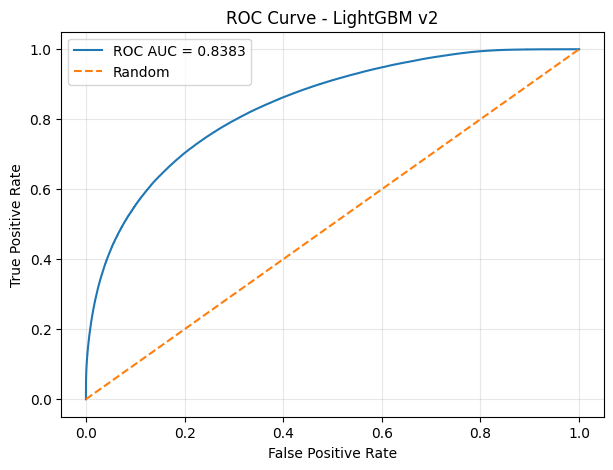

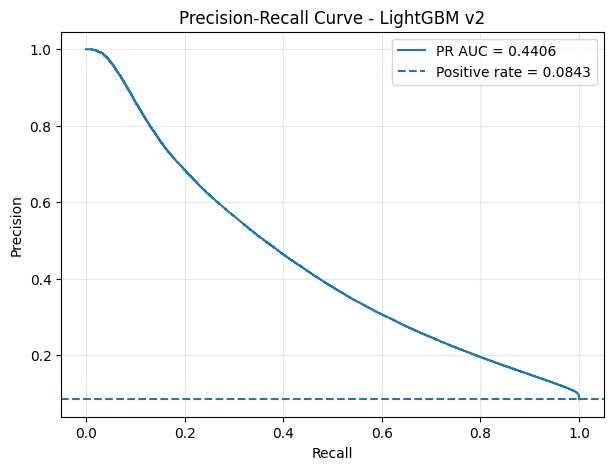

Nhận xét:
- ROC Curve thể hiện khả năng phân biệt positive/negative tổng quát.
- Precision-Recall Curve quan trọng hơn trong bài toán recommendation vì dữ liệu positive rất ít.
- Đường PR nằm càng cao hơn positive rate gốc thì mô hình càng có giá trị.


In [29]:
# ============================================================
# 20.4. ROC Curve và Precision-Recall Curve
# ============================================================
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fpr, tpr, _ = roc_curve(valid_y, valid_pred)
precision, recall, _ = precision_recall_curve(valid_y, valid_pred)

roc_auc_value = auc(fpr, tpr)
pr_auc_value = auc(recall, precision)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curve - LightGBM v2")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc_value:.4f}")
plt.axhline(y=positive_rate, linestyle="--", label=f"Positive rate = {positive_rate:.4f}")
plt.title("Precision-Recall Curve - LightGBM v2")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Nhận xét:")
print("- ROC Curve thể hiện khả năng phân biệt positive/negative tổng quát.")
print("- Precision-Recall Curve quan trọng hơn trong bài toán recommendation vì dữ liệu positive rất ít.")
print("- Đường PR nằm càng cao hơn positive rate gốc thì mô hình càng có giá trị.")

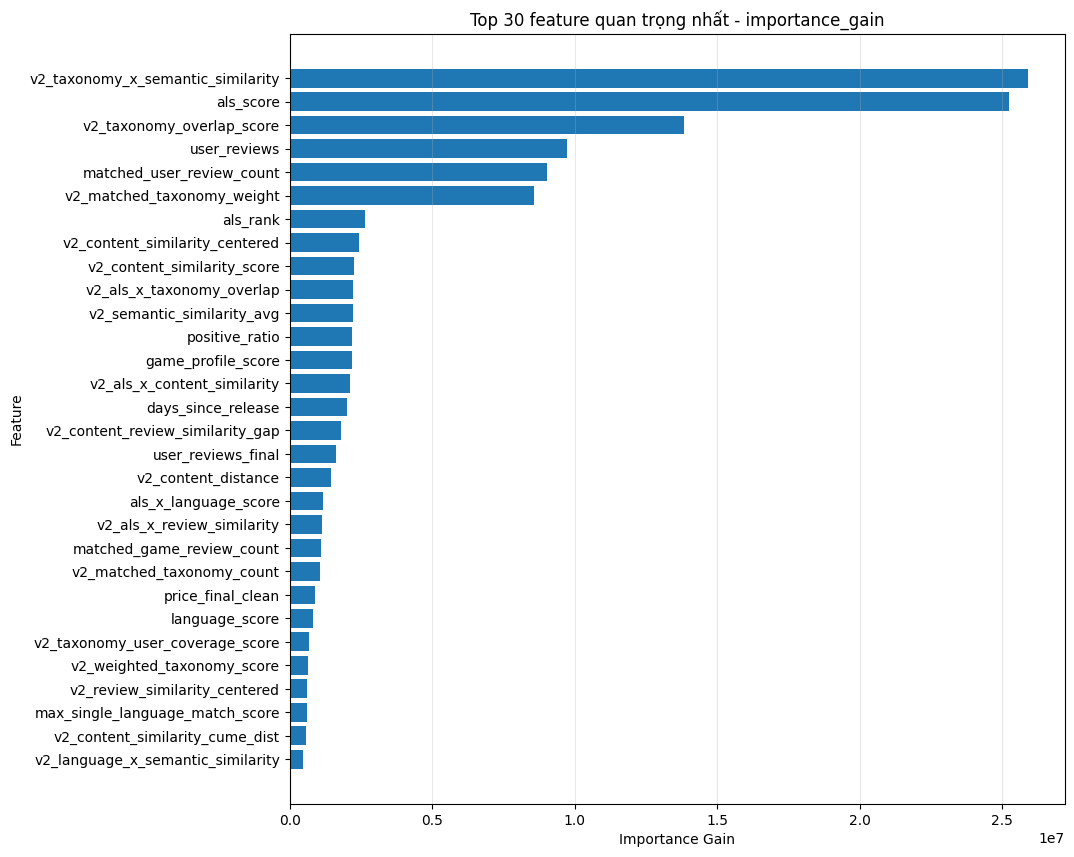

,feature,importance_gain,importance_split
0,v2_taxonomy_x_semantic_similarity,2.589479e+07,1923
1,als_score,2.522759e+07,3036
2,v2_taxonomy_overlap_score,1.382391e+07,1875
3,user_reviews,9.720039e+06,5456
4,matched_user_review_count,9.029625e+06,3229
5,v2_matched_taxonomy_weight,8.564774e+06,3046
6,als_rank,2.652539e+06,1522
7,v2_content_similarity_centered,2.425358e+06,1353
8,v2_content_similarity_score,2.252920e+06,628
9,v2_als_x_taxonomy_overlap,2.221555e+06,1573


Nhận xét:
- importance_gain cho biết feature giúp giảm loss nhiều đến mức nào khi được dùng để split.
- Nếu các feature v2 như taxonomy/content/review/language nằm cao, mô hình hybrid đã học được thêm tín hiệu ngoài ALS.
- als_score hoặc als_rank vẫn cao chứng minh ALS candidate generation vẫn là nền tảng chính.


In [30]:
# ============================================================
# 20.5. Biểu đồ feature importance top 30
# ============================================================

top_n = 30
top_imp = importance_df.sort_values("importance_gain", ascending=False).head(top_n).copy()
top_imp = top_imp.sort_values("importance_gain", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(top_imp["feature"], top_imp["importance_gain"])
plt.title(f"Top {top_n} feature quan trọng nhất - importance_gain")
plt.xlabel("Importance Gain")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.show()

display(
    importance_df.sort_values("importance_gain", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

print("Nhận xét:")
print("- importance_gain cho biết feature giúp giảm loss nhiều đến mức nào khi được dùng để split.")
print("- Nếu các feature v2 như taxonomy/content/review/language nằm cao, mô hình hybrid đã học được thêm tín hiệu ngoài ALS.")
print("- als_score hoặc als_rank vẫn cao chứng minh ALS candidate generation vẫn là nền tảng chính.")

,feature_group,total_gain,total_split,feature_count,gain_percent
9,Taxonomy,5.104819e+07,11786,9,38.767730
0,ALS / collaborative,3.532695e+07,9845,10,26.828491
8,Review / language review,2.340566e+07,14530,11,17.775058
2,MiniLM game content,1.174970e+07,8024,13,8.923126
6,Quality / popularity,2.517742e+06,3215,3,1.912059
7,Recency,2.437963e+06,4724,2,1.851472
3,Other,2.193290e+06,3523,6,1.665659
1,Language,1.478543e+06,2724,4,1.122856
5,Price,1.203149e+06,2930,5,0.913712
4,Platform,3.158101e+05,699,5,0.239837


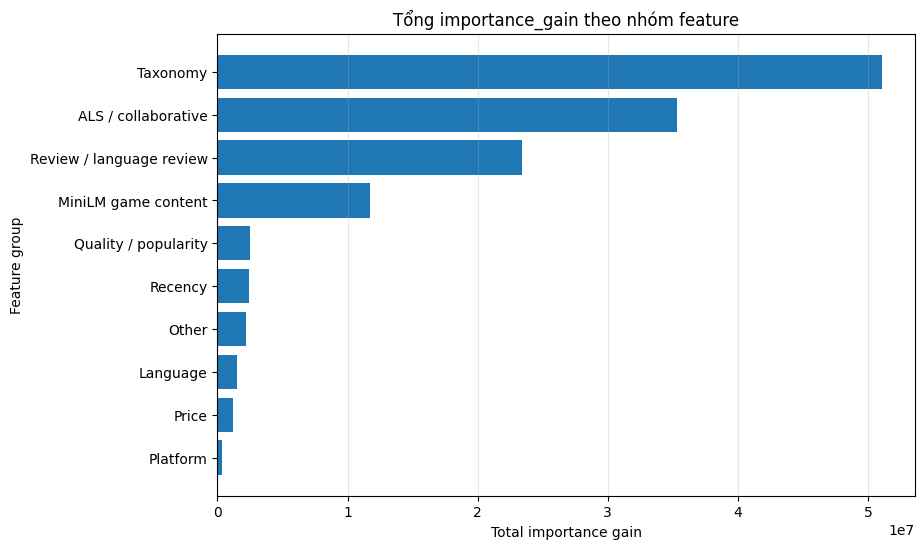

Nhận xét:
- Biểu đồ này dùng rất tốt cho báo cáo vì nó chứng minh mô hình không chỉ dựa vào một nguồn dữ liệu.
- Nếu ALS, Taxonomy, MiniLM content, Review và Language đều có gain, mô hình v2 là hybrid đúng nghĩa.


In [31]:
# ============================================================
# 20.6. Gom nhóm importance theo nguồn feature
# ============================================================

def feature_group_name(f):
    f = str(f).lower()

    if "als" in f:
        return "ALS / collaborative"
    if "taxonomy" in f or "genre" in f or "tag" in f or "category" in f:
        return "Taxonomy"
    if "content" in f or "semantic" in f:
        return "MiniLM game content"
    if "review" in f:
        return "Review / language review"
    if "language" in f:
        return "Language"
    if "price" in f or "discount" in f or "free" in f:
        return "Price"
    if "quality" in f or "positive" in f or "recommendation" in f:
        return "Quality / popularity"
    if "day" in f or "release" in f or "recency" in f:
        return "Recency"
    if "platform" in f or "linux" in f or "mac" in f or "windows" in f:
        return "Platform"
    if "user" in f:
        return "User profile"
    return "Other"

group_imp = importance_df.copy()
group_imp["feature_group"] = group_imp["feature"].apply(feature_group_name)

group_summary = (
    group_imp.groupby("feature_group", as_index=False)
    .agg(
        total_gain=("importance_gain", "sum"),
        total_split=("importance_split", "sum"),
        feature_count=("feature", "count")
    )
    .sort_values("total_gain", ascending=False)
)

group_summary["gain_percent"] = group_summary["total_gain"] / group_summary["total_gain"].sum() * 100

display(group_summary)

plot_df = group_summary.sort_values("total_gain", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature_group"], plot_df["total_gain"])
plt.title("Tổng importance_gain theo nhóm feature")
plt.xlabel("Total importance gain")
plt.ylabel("Feature group")
plt.grid(axis="x", alpha=0.3)
plt.show()

print("Nhận xét:")
print("- Biểu đồ này dùng rất tốt cho báo cáo vì nó chứng minh mô hình không chỉ dựa vào một nguồn dữ liệu.")
print("- Nếu ALS, Taxonomy, MiniLM content, Review và Language đều có gain, mô hình v2 là hybrid đúng nghĩa.")

,k,users,HitRate@K,Avg positives in topK
0,1,5000,0.1088,0.1088
1,5,5000,0.1310,0.1372
2,10,5000,0.1310,0.1374
3,20,5000,0.1310,0.1374


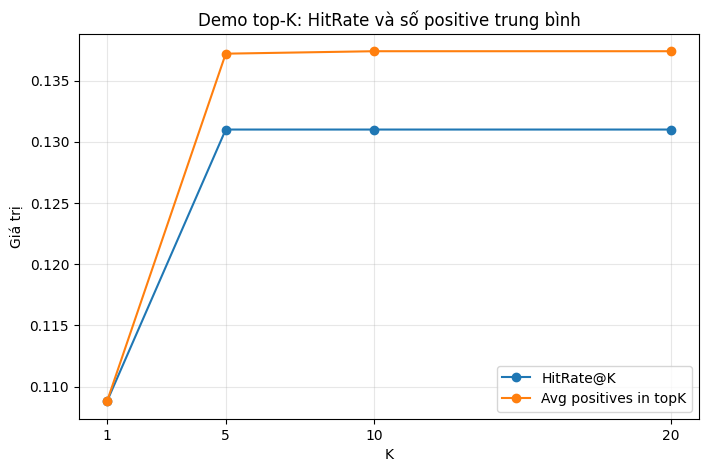

Nhận xét:
- HitRate@K cho biết tỷ lệ user có ít nhất 1 item đúng trong top-K.
- Avg positives in topK cho biết trung bình mỗi user có bao nhiêu item positive trong top-K.
- Đây là chỉ số trực quan dễ giải thích khi demo hệ thống recommend.


In [32]:
# ============================================================
# 20.7. Phân tích file demo top-K
# ============================================================

demo_summary = []

for k in [1, 5, 10, 20]:
    topk = demo_top[demo_top["rank"] <= k].copy()

    user_hit = topk.groupby("user_id")["label"].max()
    hitrate = user_hit.mean()

    avg_positive_in_topk = topk.groupby("user_id")["label"].sum().mean()

    demo_summary.append({
        "k": k,
        "users": topk["user_id"].nunique(),
        "HitRate@K": hitrate,
        "Avg positives in topK": avg_positive_in_topk
    })

demo_summary_df = pd.DataFrame(demo_summary)
display(demo_summary_df)

plt.figure(figsize=(8, 5))
plt.plot(demo_summary_df["k"], demo_summary_df["HitRate@K"], marker="o", label="HitRate@K")
plt.plot(demo_summary_df["k"], demo_summary_df["Avg positives in topK"], marker="o", label="Avg positives in topK")
plt.title("Demo top-K: HitRate và số positive trung bình")
plt.xlabel("K")
plt.ylabel("Giá trị")
plt.xticks(demo_summary_df["k"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Nhận xét:")
print("- HitRate@K cho biết tỷ lệ user có ít nhất 1 item đúng trong top-K.")
print("- Avg positives in topK cho biết trung bình mỗi user có bao nhiêu item positive trong top-K.")
print("- Đây là chỉ số trực quan dễ giải thích khi demo hệ thống recommend.")

,user_id,positive_in_top20
1090,76561198054238987,3
4136,76561198876662705,2
3179,76561198313226860,2
4184,76561198888945125,2
1903,76561198116908683,2
1032,76561198050019099,2
1617,76561198088715454,2
1152,76561198058667606,2
3787,76561198446978733,2
149,76561197979958847,2


,user_id,app_id,label,lgbm_score,rank
0,76561198054238987,108710,0,0.914548,1
1,76561198054238987,57300,1,0.877196,2
2,76561198054238987,220240,1,0.870981,3
3,76561198054238987,35140,1,0.855603,4
4,76561198116908683,105600,0,0.859801,1
5,76561198116908683,377160,0,0.855222,2
6,76561198116908683,203160,1,0.784338,3
7,76561198116908683,397540,0,0.768061,4
8,76561198116908683,201810,1,0.726703,5
9,76561198313226860,400,1,0.944932,1


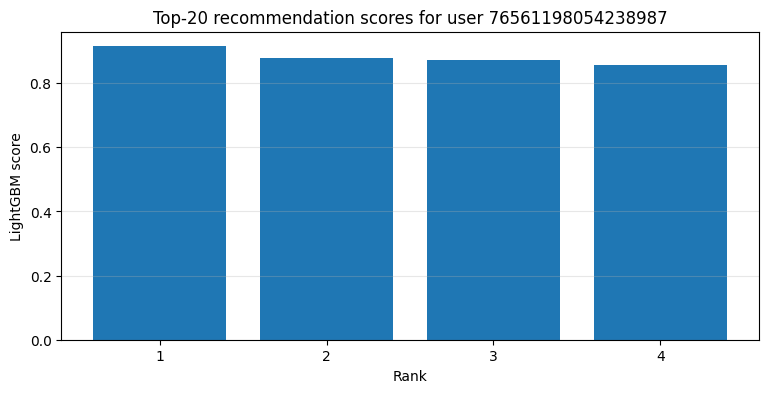

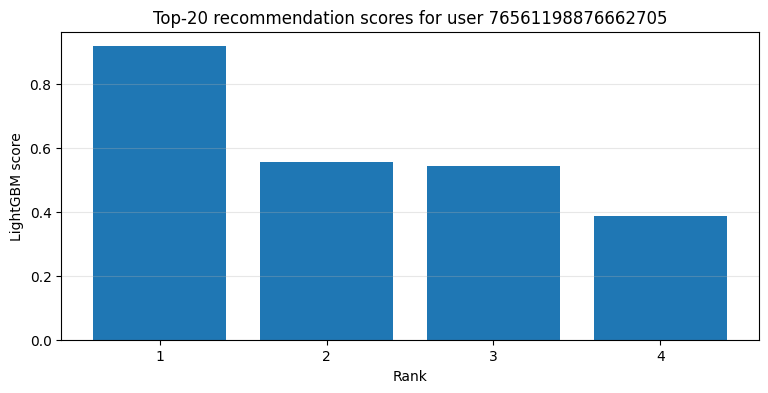

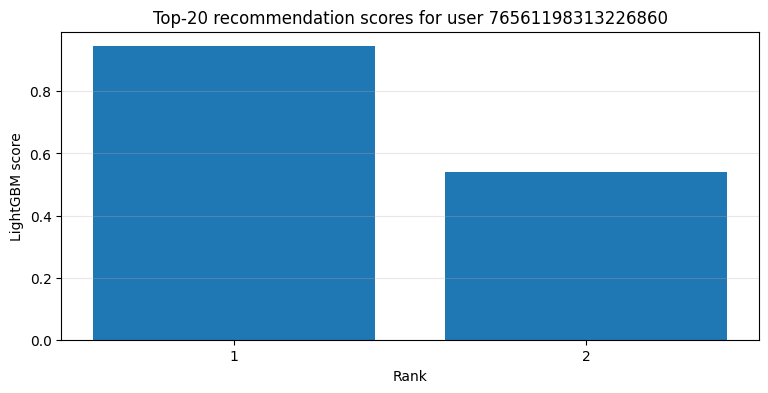

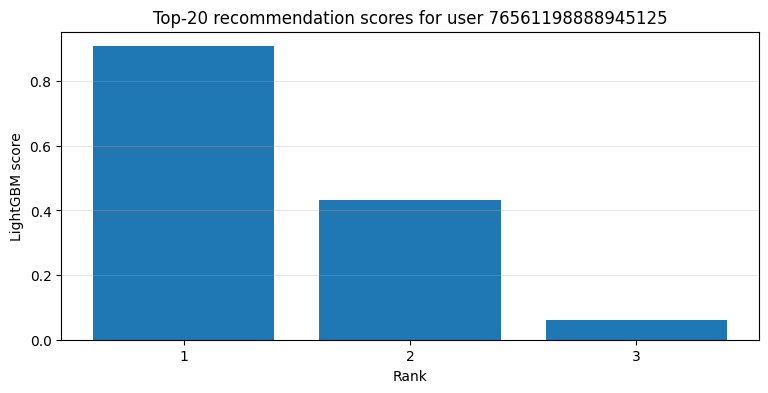

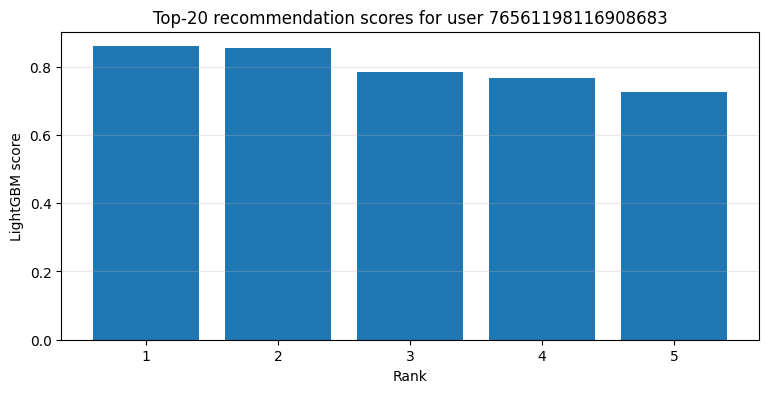

Nhận xét:
- Cell này chọn các user có ít nhất một positive trong top-20 để bạn đưa vào slide/demo.
- Khi demo với thầy, nên join thêm game title để dễ hiểu hơn app_id.


In [33]:
# ============================================================
# 20.8. Chọn một vài user có hit positive để demo trực quan
# ============================================================

user_hit_count = (
    demo_top.groupby("user_id")["label"]
    .sum()
    .reset_index(name="positive_in_top20")
    .sort_values("positive_in_top20", ascending=False)
)

display(user_hit_count.head(20))

demo_good_users = user_hit_count[user_hit_count["positive_in_top20"] > 0]["user_id"].head(5).tolist()

if len(demo_good_users) == 0:
    print("Không tìm thấy user có label=1 trong top20 demo. Có thể cần tăng MAX_DEMO_USERS hoặc kiểm tra candidate validation.")
else:
    demo_good = (
        demo_top[demo_top["user_id"].isin(demo_good_users)]
        .sort_values(["user_id", "rank"])
        .reset_index(drop=True)
    )

    display(demo_good)

    for uid in demo_good_users:
        g = demo_good[demo_good["user_id"] == uid].sort_values("rank")
        plt.figure(figsize=(9, 4))
        plt.bar(g["rank"].astype(str), g["lgbm_score"])
        plt.title(f"Top-20 recommendation scores for user {uid}")
        plt.xlabel("Rank")
        plt.ylabel("LightGBM score")
        plt.grid(axis="y", alpha=0.3)
        plt.show()

print("Nhận xét:")
print("- Cell này chọn các user có ít nhất một positive trong top-20 để bạn đưa vào slide/demo.")
print("- Khi demo với thầy, nên join thêm game title để dễ hiểu hơn app_id.")

In [34]:
# ============================================================
# 20.9. Lưu bảng phân tích ra Drive
# ============================================================

analysis_dir = os.path.join(DRIVE_OUT_DIR, "analysis_outputs")
os.makedirs(analysis_dir, exist_ok=True)

summary_eval_path = os.path.join(analysis_dir, "classification_summary.csv")
group_importance_path = os.path.join(analysis_dir, "feature_group_importance.csv")
demo_summary_path = os.path.join(analysis_dir, "demo_topk_summary.csv")
user_hit_path = os.path.join(analysis_dir, "demo_user_hit_count.csv")

summary_eval_df.to_csv(summary_eval_path, index=False)
group_summary.to_csv(group_importance_path, index=False)
demo_summary_df.to_csv(demo_summary_path, index=False)
user_hit_count.to_csv(user_hit_path, index=False)

print("Saved analysis files:")
print(summary_eval_path)
print(group_importance_path)
print(demo_summary_path)
print(user_hit_path)

Saved analysis files:
/content/drive/MyDrive/steam_lgbm_v2_memmap_eta/analysis_outputs/classification_summary.csv
/content/drive/MyDrive/steam_lgbm_v2_memmap_eta/analysis_outputs/feature_group_importance.csv
/content/drive/MyDrive/steam_lgbm_v2_memmap_eta/analysis_outputs/demo_topk_summary.csv
/content/drive/MyDrive/steam_lgbm_v2_memmap_eta/analysis_outputs/demo_user_hit_count.csv
